# Notebook 16: robustness of the route-order comparison

## Purpose

This notebook tests whether the principal route-order conclusion is robust to reasonable coarse-graining choices.

The previously established comparison found that:

1. continuum-first reduction,
   $\mathrm{DEM}\rightarrow\mathrm{CG}\rightarrow\mathrm{POD}$,

substantially outperformed:

2. particle-first reduction,
   $\mathrm{DEM}\rightarrow\mathrm{particle\ POD}\rightarrow\mathrm{CG}$.

The earlier result used one validated coarse-graining configuration. This notebook tests whether that conclusion persists across selected grid resolutions and Lucy-kernel cutoffs.

## Proposed fixed design

The proposed representative parameter cases are:

- particle-size ratio $1.000000$;
- particle-size ratio approximately $1.494949$;
- particle-size ratio $2.000000$.

The proposed sensitivity levels are:

- grid resolution: $75\times75$, $100\times100$, and $125\times125$;
- Lucy cutoff: $2$, $3$, and $4$;
- retained rank: $27$ and $100$.

The existing matched temporal training and validation split will be preserved.

The primary quantity will be the ratio of particle-first to continuum-first held-out field error under the same coarse-graining configuration.

This is a robustness analysis, not an optimisation exercise. Coarse-graining settings will not be selected according to which produces a preferred conclusion. All tested combinations and any failures will be retained.

## Scope and safeguards

- Existing notebooks and artifacts will remain unchanged.
- No external test case will be used for tuning or selection.
- The three parameter cases are representative training-case diagnostics, not independent parameter-prediction tests.
- Grid and kernel effects will be reported as effect sizes.
- Computational costs will distinguish offline processing from online prediction.
- No end-to-end DEM speed-up will be claimed unless a corresponding DEM runtime was actually recorded.
- Particle-first conclusions remain specific to the tested coordinate-POD formulation.
- This preflight performs no coarse-graining and writes no artifacts.

In [2]:
from pathlib import Path
import ast
import json
import platform
import sys
import zipfile

import nbformat
import numpy as np
import pandas as pd


PROJECT_ROOT = Path.cwd().resolve()

while not (
    PROJECT_ROOT
    / ".git"
).exists():
    parent = PROJECT_ROOT.parent

    if parent == PROJECT_ROOT:
        raise RuntimeError(
            "Could not locate the repository root."
        )

    PROJECT_ROOT = parent


NOTEBOOK_DIRECTORY = (
    PROJECT_ROOT
    / "notebooks"
)

PROCESSED_DATA_DIRECTORY = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

RESULT_TABLE_DIRECTORY = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULT_FIGURE_DIRECTORY = (
    PROJECT_ROOT
    / "results"
    / "figures"
)


required_notebooks = [
    NOTEBOOK_DIRECTORY
    / "11_particle_level_pod.ipynb",
    NOTEBOOK_DIRECTORY
    / "12_multi_parameter_route_order.ipynb",
    NOTEBOOK_DIRECTORY
    / "13_xz_particle_representation_sensitivity.ipynb",
    NOTEBOOK_DIRECTORY
    / "15_statistical_uncertainty_accuracy_floor.ipynb",
]


print(
    "Project root:",
    PROJECT_ROOT,
)

print(
    "Python executable:",
    sys.executable,
)

print(
    "Python version:",
    platform.python_version(),
)

print(
    "NumPy version:",
    np.__version__,
)

print(
    "Pandas version:",
    pd.__version__,
)


print(
    "\nRequired upstream notebooks:"
)

for path in required_notebooks:
    print(
        path.relative_to(
            PROJECT_ROOT
        ),
        "exists:",
        path.is_file(),
    )


assert all(
    path.is_file()
    for path in required_notebooks
), (
    "One or more required upstream notebooks are missing."
)

assert (
    ".venv"
    in Path(
        sys.executable
    ).parts
), (
    "Notebook 16 is not using the repository .venv."
)

print(
    "\nNotebook 16 read-only preflight passed:",
    True,
)

Project root: /Users/rallen/Documents/msc-rom-particle-systems
Python executable: /Users/rallen/Documents/msc-rom-particle-systems/.venv/bin/python
Python version: 3.12.1
NumPy version: 1.26.4
Pandas version: 3.0.3

Required upstream notebooks:
notebooks/11_particle_level_pod.ipynb exists: True
notebooks/12_multi_parameter_route_order.ipynb exists: True
notebooks/13_xz_particle_representation_sensitivity.ipynb exists: True
notebooks/15_statistical_uncertainty_accuracy_floor.ipynb exists: True

Notebook 16 read-only preflight passed: True


In [3]:
def read_npz_header_schema(
    path,
):
    records = []

    with zipfile.ZipFile(
        path,
        mode="r",
    ) as archive:
        for member_name in sorted(
            archive.namelist()
        ):
            if not member_name.endswith(
                ".npy"
            ):
                continue

            with archive.open(
                member_name,
                mode="r",
            ) as stream:
                version = (
                    np.lib.format.read_magic(
                        stream
                    )
                )

                if version == (
                    1,
                    0,
                ):
                    (
                        shape,
                        fortran_order,
                        dtype,
                    ) = (
                        np.lib.format.read_array_header_1_0(
                            stream
                        )
                    )
                elif version in [
                    (
                        2,
                        0,
                    ),
                    (
                        3,
                        0,
                    ),
                ]:
                    (
                        shape,
                        fortran_order,
                        dtype,
                    ) = (
                        np.lib.format.read_array_header_2_0(
                            stream
                        )
                    )
                else:
                    raise ValueError(
                        "Unsupported NPY version "
                        f"{version} in {path}"
                    )

            records.append(
                {
                    "key": Path(
                        member_name
                    ).stem,
                    "shape": shape,
                    "dtype": str(
                        dtype
                    ),
                    "fortran_order": (
                        fortran_order
                    ),
                }
            )

    return records


search_terms = (
    "particle",
    "route",
    "multi_parameter",
    "compact",
    "pilot",
)

candidate_npz_paths = sorted(
    path
    for path in (
        PROCESSED_DATA_DIRECTORY.rglob(
            "*.npz"
        )
    )
    if any(
        term
        in str(
            path.relative_to(
                PROJECT_ROOT
            )
        ).lower()
        for term in search_terms
    )
)


print(
    "Relevant compact NPZ candidates:",
    len(
        candidate_npz_paths
    ),
)


for path in candidate_npz_paths:
    print(
        "\n",
        path.relative_to(
            PROJECT_ROOT
        ),
        sep="",
    )

    try:
        schema = (
            read_npz_header_schema(
                path
            )
        )

        for record in schema:
            print(
                "  ",
                record[
                    "key"
                ],
                "shape=",
                record[
                    "shape"
                ],
                "dtype=",
                record[
                    "dtype"
                ],
            )
    except Exception as error:
        print(
            "  HEADER INSPECTION FAILED:",
            repr(
                error
            ),
        )


candidate_manifest_paths = sorted(
    {
        path
        for pattern in [
            "*.json",
            "*.csv",
        ]
        for path in (
            list(
                PROCESSED_DATA_DIRECTORY.rglob(
                    pattern
                )
            )
            + list(
                RESULT_TABLE_DIRECTORY.rglob(
                    pattern
                )
            )
        )
        if any(
            term
            in str(
                path.relative_to(
                    PROJECT_ROOT
                )
            ).lower()
            for term in search_terms
        )
    }
)


print(
    "\nRelevant manifest/table candidates:",
    len(
        candidate_manifest_paths
    ),
)

for path in candidate_manifest_paths:
    print(
        path.relative_to(
            PROJECT_ROOT
        )
    )


print(
    "\nNo numerical NPZ arrays were loaded:",
    True,
)

print(
    "No files were written:",
    True,
)

Relevant compact NPZ candidates: 0

Relevant manifest/table candidates: 62
results/tables/multi_parameter_route_order/multi_parameter_error_ratio_by_rank.csv
results/tables/multi_parameter_route_order/multi_parameter_rank_100_physical_summary.csv
results/tables/multi_parameter_route_order/multi_parameter_rank_100_summary.csv
results/tables/multi_parameter_route_order/multi_parameter_rank_aggregate_summary.csv
results/tables/multi_parameter_route_order/multi_parameter_route_order_average_all_cases.csv
results/tables/multi_parameter_route_order/multi_parameter_route_order_energy_all_cases.csv
results/tables/multi_parameter_route_order/multi_parameter_route_order_manifest.json
results/tables/multi_parameter_route_order/multi_parameter_route_order_time_resolved_all_cases.csv
results/tables/multi_parameter_route_order/remaining_case_batch_progress.csv
results/tables/multi_parameter_route_order/route_order_average_ratio_1_000000_num_1.csv
results/tables/multi_parameter_route_order/route_orde

In [4]:
upstream_function_records = []


for notebook_path in (
    required_notebooks[
        :3
    ]
):
    notebook = nbformat.read(
        notebook_path,
        as_version=4,
    )

    for cell_index, cell in enumerate(
        notebook.cells,
        start=1,
    ):
        if (
            cell.cell_type
            != "code"
        ):
            continue

        source = cell.source

        try:
            tree = ast.parse(
                source
            )
        except SyntaxError:
            continue

        for node in ast.walk(
            tree
        ):
            if isinstance(
                node,
                (
                    ast.FunctionDef,
                    ast.AsyncFunctionDef,
                ),
            ):
                upstream_function_records.append(
                    {
                        "notebook": (
                            notebook_path.name
                        ),
                        "cell": cell_index,
                        "function": node.name,
                        "line_count": (
                            node.end_lineno
                            - node.lineno
                            + 1
                        ),
                    }
                )


upstream_function_summary = (
    pd.DataFrame(
        upstream_function_records
    )
    .sort_values(
        [
            "notebook",
            "cell",
            "function",
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    upstream_function_summary
)


relevant_function_mask = (
    upstream_function_summary[
        "function"
    ]
    .str.lower()
    .str.contains(
        (
            "coarse"
            "|cg"
            "|lucy"
            "|grid"
            "|particle"
            "|pod"
            "|field"
            "|snapshot"
        ),
        regex=True,
    )
)


print(
    "\nPotentially reusable functions:"
)

display(
    upstream_function_summary.loc[
        relevant_function_mask
    ].reset_index(
        drop=True
    )
)


print(
    "Function inventory completed:",
    True,
)

,notebook,cell,function,line_count
0,11_particle_level_pod.ipynb,2,locate_project_root,15
1,11_particle_level_pod.ipynb,2,sha256_file,12
2,11_particle_level_pod.ipynb,4,calculate_thin_pod,37
3,11_particle_level_pod.ipynb,7,descriptive_error_table,75
4,11_particle_level_pod.ipynb,8,blocked_projection_error_table,98
...,...,...,...,...
59,13_xz_particle_representation_sensitivity.ipynb,15,save_xz_result,202
60,13_xz_particle_representation_sensitivity.ipynb,15,write_csv_atomic,16
61,13_xz_particle_representation_sensitivity.ipynb,15,xz_checkpoint_state,17
62,13_xz_particle_representation_sensitivity.ipynb,15,xz_result_paths,21



Potentially reusable functions:


,notebook,cell,function,line_count
0,11_particle_level_pod.ipynb,4,calculate_thin_pod,37
1,11_particle_level_pod.ipynb,15,reconstruct_validation_snapshot,23
2,11_particle_level_pod.ipynb,23,lucy_kernel_2d,24
3,11_particle_level_pod.ipynb,23,trapezoidal_snapshot_weights,25
4,11_particle_level_pod.ipynb,26,coarse_grain_arithmetic_average,42
5,11_particle_level_pod.ipynb,26,coarse_grain_small_species_snapshot,43
6,11_particle_level_pod.ipynb,27,compare_field_to_cycle_two,68
7,11_particle_level_pod.ipynb,27,field_centroid,9
8,11_particle_level_pod.ipynb,30,coarse_grain_snapshot_stack,42
9,11_particle_level_pod.ipynb,35,snapshot_correlations,38


Function inventory completed: True


In [5]:
import json
import re

manifest_directory = (
    RESULT_TABLE_DIRECTORY
    / "multi_parameter_route_order"
)

manifest_names = [
    "multi_parameter_route_order_manifest.json",
    "route_order_manifest_ratio_1_000000_num_1.json",
    "route_order_manifest_ratio_1_494949_num_50.json",
    "route_order_manifest_ratio_2_000000_num_100.json",
]

robustness_manifests = {}
robustness_recorded_storage_paths = []


def preview_manifest(value):
    """Abbreviate long lists for display; leave originals unchanged."""
    if isinstance(value, dict):
        return {
            key: preview_manifest(item)
            for key, item in value.items()
        }

    if isinstance(value, list):
        if len(value) > 8:
            return {
                "DISPLAY_ONLY_list_length": len(value),
                "DISPLAY_ONLY_first_two_items": [
                    preview_manifest(item)
                    for item in value[:2]
                ],
            }

        return [preview_manifest(item) for item in value]

    return value


def iter_manifest_scalars(value, location="$"):
    """Visit all scalar entries, including abbreviated lists."""
    if isinstance(value, dict):
        for key, item in value.items():
            yield from iter_manifest_scalars(
                item,
                f"{location}.{key}",
            )

    elif isinstance(value, list):
        for index, item in enumerate(value):
            yield from iter_manifest_scalars(
                item,
                f"{location}[{index}]",
            )

    else:
        yield location, value


for name in manifest_names:
    path = manifest_directory / name

    assert path.is_file(), f"Missing saved manifest: {path}"

    with path.open("r", encoding="utf-8") as stream:
        document = json.load(stream)

    robustness_manifests[name] = document

    print(f"\nMANIFEST: {name}")
    print(json.dumps(preview_manifest(document), indent=2))

    for location, value in iter_manifest_scalars(document):
        if not isinstance(value, str):
            continue

        if (
            re.search(r"\.np[yz](?:$|[?#])", value, re.IGNORECASE)
            or "compact" in location.lower()
            or "cache" in location.lower()
        ):
            robustness_recorded_storage_paths.append(
                {
                    "manifest": name,
                    "json_location": location,
                    "recorded_value": value,
                }
            )


print("\nRECORDED ARRAY / COMPACT / CACHE REFERENCES")

if robustness_recorded_storage_paths:
    print(
        pd.DataFrame(
            robustness_recorded_storage_paths
        ).to_string(index=False)
    )
else:
    print("No matching references found in these four manifests.")


print("\nOnly the four named JSON manifests were read.")
print("Referenced files were not opened; no files were written.")


MANIFEST: multi_parameter_route_order_manifest.json
{
  "schema_version": 1,
  "notebook": "12_multi_parameter_route_order.ipynb",
  "experiment": {
    "case_count": 5,
    "size_ratios": [
      1.0,
      1.252525,
      1.494949,
      1.747475,
      2.0
    ],
    "ranks": [
      0,
      8,
      14,
      27,
      100
    ],
    "training_snapshots_per_case": 101,
    "validation_snapshots_per_case": 99,
    "comparison_time_max": 1720.72,
    "particle_representation": "labelled XYZ coordinates",
    "continuum_representation": "small-species XZ volume fraction"
  },
  "pilot_regression": {
    "maximum_average_table_difference": 1.1368683772161603e-13,
    "maximum_time_table_difference": 1.5218430817930245e-13
  },
  "descriptive_rank_100_trends": {
    "continuum_error_strictly_decreases": true,
    "particle_error_strictly_increases": true,
    "error_ratio_strictly_increases": true,
    "continuum_error_range_percent": [
      4.556878570587827,
      9.04242063358271


In [6]:
print("COMPLETE UPSTREAM FUNCTION INVENTORY")
print(upstream_function_summary.to_string(index=False))


notebook12_path = (
    NOTEBOOK_DIRECTORY
    / "12_multi_parameter_route_order.ipynb"
)

notebook12 = nbformat.read(
    notebook12_path,
    as_version=4,
)

wanted_functions = {
    "lucy_kernel_2d",
    "coarse_grain_small_species_snapshot",
    "coarse_grain_snapshot_stack",
    "calculate_thin_pod",
}

found_functions = set()


for cell_number, cell in enumerate(
    notebook12.cells,
    start=1,
):
    if cell.cell_type != "code":
        continue

    try:
        tree = ast.parse(cell.source)
    except SyntaxError:
        print(
            f"Cell {cell_number}: not plain Python; "
            "source inspection skipped."
        )
        continue

    for node in ast.walk(tree):
        if (
            isinstance(
                node,
                (ast.FunctionDef, ast.AsyncFunctionDef),
            )
            and node.name in wanted_functions
        ):
            found_functions.add(node.name)

            print(
                f"\nNOTEBOOK 12 — CELL {cell_number}"
                f" — {node.name}"
            )
            print(ast.get_source_segment(cell.source, node))


assert wanted_functions <= found_functions, (
    "Some requested function definitions were not found: "
    f"{sorted(wanted_functions - found_functions)}"
)


print("\nSTORAGE AND CG-SETTING SOURCE EXCERPTS")

source_pattern = re.compile(
    r"\.np[yz]\b"
    r"|np\.(?:load|save|savez|savez_compressed)\s*\("
    r"|\b(?:COMPACT|CACHE|CG|GRID|KERNEL|CUTOFF|WIDTH|AXIAL)"
    r"[A-Z0-9_]*\s*="
)


for notebook_path in required_notebooks[1:3]:
    notebook = nbformat.read(
        notebook_path,
        as_version=4,
    )

    for cell_number, cell in enumerate(
        notebook.cells,
        start=1,
    ):
        if cell.cell_type != "code":
            continue

        lines = cell.source.splitlines()
        selected_lines = set()

        for index, line in enumerate(lines):
            if source_pattern.search(line):
                selected_lines.update(
                    range(
                        max(0, index - 4),
                        min(len(lines), index + 5),
                    )
                )

        if not selected_lines:
            continue

        print(
            f"\n{notebook_path.name}"
            f" — CELL {cell_number}"
        )

        previous_index = None

        for index in sorted(selected_lines):
            if (
                previous_index is not None
                and index > previous_index + 1
            ):
                print("    ...")

            print(f"{index + 1:4d}: {lines[index]}")
            previous_index = index


print("\nSource inspection complete.")
print("No extracted function was executed.")
print("No particle files or numerical arrays were read.")
print("No files were written.")

COMPLETE UPSTREAM FUNCTION INVENTORY
                                       notebook  cell                             function  line_count
                    11_particle_level_pod.ipynb     2                  locate_project_root          15
                    11_particle_level_pod.ipynb     2                          sha256_file          12
                    11_particle_level_pod.ipynb     4                   calculate_thin_pod          37
                    11_particle_level_pod.ipynb     7              descriptive_error_table          75
                    11_particle_level_pod.ipynb     8       blocked_projection_error_table          98
                    11_particle_level_pod.ipynb    14            symmetric_species_nn_rmse          50
                    11_particle_level_pod.ipynb    15      reconstruct_validation_snapshot          23
                    11_particle_level_pod.ipynb    18 reconstruct_all_validation_positions          20
                    11_particle_leve

In [7]:
import hashlib
import math
import zipfile


n16_cache_paths = {
    "ratio_1_000000_num_1": (
        PROJECT_ROOT
        / "data/interim/particle_positions_ratio_1_000000_num_1.npz"
    ),
    "ratio_1_494949_num_50": (
        PROJECT_ROOT
        / "data/interim/multi_parameter_route_order"
        / "particle_positions_ratio_1_494949_num_50.npz"
    ),
    "ratio_2_000000_num_100": (
        PROJECT_ROOT
        / "data/interim/multi_parameter_route_order"
        / "particle_positions_ratio_2_000000_num_100.npz"
    ),
}


def n16_sha256_file(path):
    digest = hashlib.sha256()

    with path.open("rb") as stream:
        for block in iter(
            lambda: stream.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def n16_read_array_headers(path):
    """Read array headers without materialising numerical arrays."""
    records = []

    with zipfile.ZipFile(path, mode="r") as archive:
        for member in sorted(archive.namelist()):
            if not member.endswith(".npy"):
                continue

            with archive.open(member, mode="r") as stream:
                version = np.lib.format.read_magic(stream)

                if version == (1, 0):
                    reader = np.lib.format.read_array_header_1_0
                elif version == (2, 0):
                    reader = np.lib.format.read_array_header_2_0
                else:
                    raise ValueError(
                        f"Unsupported header version {version}: "
                        f"{path.name}/{member}. Stop for inspection."
                    )

                shape, fortran_order, dtype = reader(stream)

            records.append(
                {
                    "key": member[:-4],
                    "shape": shape,
                    "dtype": str(dtype),
                    "fortran_order": fortran_order,
                    "contains_objects": dtype.hasobject,
                    "array_bytes": (
                        math.prod(shape) * dtype.itemsize
                    ),
                }
            )

    assert records, f"No array headers found: {path}"
    return records


aggregate_manifest = robustness_manifests[
    "multi_parameter_route_order_manifest.json"
]

n16_case_manifests = {}
n16_cache_schemas = {}
n16_cache_audit_rows = []


for case_id, cache_path in n16_cache_paths.items():
    print(f"\nCASE: {case_id}")

    # Verify the case manifest against the aggregate manifest.
    manifest_record = aggregate_manifest["case_manifests"][case_id]
    manifest_path = PROJECT_ROOT / manifest_record["relative_path"]

    assert manifest_path.is_file(), (
        f"Missing case manifest: {manifest_path}"
    )

    manifest_bytes = manifest_path.read_bytes()
    manifest_hash = hashlib.sha256(manifest_bytes).hexdigest()

    assert manifest_hash == manifest_record["sha256"], (
        f"Case-manifest hash mismatch: {case_id}"
    )

    case_manifest = json.loads(manifest_bytes)
    assert case_manifest["case"]["case_id"] == case_id

    n16_case_manifests[case_id] = case_manifest

    # Do not rebuild or search elsewhere if a cache is missing.
    print("Cache:", cache_path)
    print("Exists:", cache_path.is_file())

    assert cache_path.is_file(), (
        f"Missing compact cache: {cache_path}. "
        "Stop here; do not rebuild it from raw data."
    )

    expected_hash = case_manifest["validation"][
        "compact_artifact_sha256"
    ]
    observed_hash = n16_sha256_file(cache_path)

    print("Expected SHA-256:", expected_hash)
    print("Observed SHA-256:", observed_hash)

    assert observed_hash == expected_hash, (
        f"Compact-cache hash mismatch: {case_id}"
    )

    schema = n16_read_array_headers(cache_path)
    n16_cache_schemas[case_id] = schema

    print("\nArray headers:")
    print(pd.DataFrame(schema).to_string(index=False))

    n16_cache_audit_rows.append(
        {
            "case_id": case_id,
            "manifest_hash_match": True,
            "cache_hash_match": True,
            "compressed_file_MiB": (
                cache_path.stat().st_size / 1024**2
            ),
            "uncompressed_array_payload_MiB": (
                sum(row["array_bytes"] for row in schema)
                / 1024**2
            ),
            "array_count": len(schema),
        }
    )


n16_cache_audit = pd.DataFrame(n16_cache_audit_rows)

print("\nCACHE AUDIT SUMMARY")
print(n16_cache_audit.to_string(index=False))

print("\nThree compact-cache hashes verified:", len(n16_cache_audit) == 3)
print("Numerical arrays materialised:", False)
print("Raw DEM files accessed:", False)
print("Files written:", False)


CASE: ratio_1_000000_num_1
Cache: /Users/rallen/Documents/msc-rom-particle-systems/data/interim/particle_positions_ratio_1_000000_num_1.npz
Exists: True
Expected SHA-256: 97bddffd33e2bcf8f6863cf29d5f82f5268c9a225bdac3f4399ca4704db3a9a1
Observed SHA-256: 97bddffd33e2bcf8f6863cf29d5f82f5268c9a225bdac3f4399ca4704db3a9a1

Array headers:
                    key           shape   dtype  fortran_order  contains_objects  array_bytes
           cycle_labels          (201,)     <U7          False             False         5628
         particle_radii        (10792,) float64          False             False        86336
          positions_xyz (201, 10792, 3) float64          False             False     52060608
         snapshot_times          (201,) float64          False             False         1608
    source_byte_offsets          (201,)   int64          False             False         1608
source_snapshot_numbers          (201,)   int64          False             False         1608
      

In [8]:
# %% CELL 5: frozen grids and regression tables
import ast
import hashlib
import json
from pathlib import Path
from time import perf_counter

import nbformat
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

N16_RANKS = (27, 100)
N16_SUPPORT_RADIUS = 3.0
N16_AXIAL_LENGTH = 10.0
N16_TIME_MAX = 1720.72
N16_TIME_ATOL = 1e-8
N16_REGRESSION_ATOL = 1e-8
N16_REGRESSION_RTOL = 1e-9
N16_CASE_IDS = (
    "ratio_1_000000_num_1",
    "ratio_1_494949_num_50",
    "ratio_2_000000_num_100",
)
n16_input_hashes = {}


def n16_saved_path(path):
    path = Path(path).resolve()
    assert path.is_relative_to(PROJECT_ROOT), f"Outside repository: {path}"
    assert not path.is_relative_to(PROJECT_ROOT / "data/raw"), path
    assert path.is_file(), f"Missing saved input: {path}"
    return path


def n16_read_saved_json(path):
    path = n16_saved_path(path)
    content = path.read_bytes()
    n16_input_hashes[str(path)] = hashlib.sha256(content).hexdigest()
    return json.loads(content)


def n16_verified_record(record):
    path = n16_saved_path(PROJECT_ROOT / record["relative_path"])
    observed = n16_sha256_file(path)
    assert observed == record["sha256"], f"Hash mismatch: {path}"
    n16_input_hashes[str(path)] = observed
    return path


n16_aggregate = n16_read_saved_json(
    RESULT_TABLE_DIRECTORY / "multi_parameter_route_order"
    / "multi_parameter_route_order_manifest.json"
)
n16_case_manifests = {}
for case_id in N16_CASE_IDS:
    path = n16_verified_record(n16_aggregate["case_manifests"][case_id])
    manifest = n16_read_saved_json(path)
    assert manifest["case"]["case_id"] == case_id
    config = manifest["configuration"]
    assert config["comparison_time_max"] == N16_TIME_MAX
    assert config["lucy_cutoff"] == N16_SUPPORT_RADIUS
    assert config["axial_averaging_length"] == N16_AXIAL_LENGTH
    assert config["small_species"] == 1
    n16_case_manifests[case_id] = manifest

n16_grid_manifest = n16_read_saved_json(
    RESULT_TABLE_DIRECTORY / "exact_paper_method_reproduction"
    / "exact_paper_method_reproduction_manifest.json"
)
assert n16_grid_manifest["dataset"]["relative_path"] == (
    "data/processed/cg_phi_small_dataset.npz"
)
n16_grid_path = n16_verified_record(n16_grid_manifest["dataset"])
with np.load(n16_grid_path, allow_pickle=False) as saved:
    n16_x = saved["x"]
    n16_z = saved["z"]

for axis in (n16_x, n16_z):
    assert axis.shape == (100,) and np.isfinite(axis).all()
    np.testing.assert_allclose(np.diff(axis), 0.66, rtol=0, atol=1e-12)
    axis.setflags(write=False)

n16_baseline_tables = {}
for table_name, artifact_name in {
    "average": "master_average_csv",
    "time": "master_time_csv",
    "energy": "master_energy_csv",
}.items():
    path = n16_verified_record(
        n16_aggregate["aggregate_artifacts"][artifact_name]
    )
    n16_baseline_tables[table_name] = pd.read_csv(path)

print("Verified saved grid:", (len(n16_x), len(n16_z)))
print("X endpoints:", n16_x[[0, -1]])
print("Z endpoints:", n16_z[[0, -1]])
print("Baseline table rows:", {
    name: len(table) for name, table in n16_baseline_tables.items()
})
print("Only x/z were loaded from the continuum NPZ; no external truth arrays.")
print("Saved-input audit passed; no raw files opened or files written.")

Verified saved grid: (100, 100)
X endpoints: [-32.67  32.67]
Z endpoints: [-32.67  32.67]
Baseline table rows: {'average': 50, 'time': 50, 'energy': 25}
Only x/z were loaded from the continuum NPZ; no external truth arrays.
Saved-input audit passed; no raw files opened or files written.


In [9]:
# %% CELL 6: audited cache loader and exact pilot split
n16_compact_manifest_paths = {
    "ratio_1_000000_num_1": (
        RESULT_TABLE_DIRECTORY
        / "particle_snapshot_representation_ratio_1_000000_num_1.json"
    ),
    **{
        case_id: (
            PROJECT_ROOT / "data/interim/multi_parameter_route_order"
            / f"snapshot_manifest_{case_id}.json"
        )
        for case_id in N16_CASE_IDS[1:]
    },
}


def n16_load_case(case_id):
    result_manifest = n16_case_manifests[case_id]
    metadata = n16_read_saved_json(n16_compact_manifest_paths[case_id])
    record = metadata["compact_artifact"]
    assert record["sha256"] == result_manifest["validation"][
        "compact_artifact_sha256"
    ]
    path = n16_verified_record(record)
    assert path == n16_cache_paths[case_id].resolve()

    with np.load(path, allow_pickle=False) as saved:
        positions = saved["positions_xyz"]
        times = saved["snapshot_times"]
        radii = saved["particle_radii"]
        species = saved["species_index"]
        labels = saved["cycle_labels"].astype(str)
        if metadata["schema_version"] == 2:
            saved_mask = saved["comparison_time_mask"]

    if metadata["schema_version"] == 1:
        assert case_id == N16_CASE_IDS[0]
        boundary = metadata["physical_cycle_split"]["cycle_boundary_time"]
    elif metadata["schema_version"] == 2:
        assert metadata["case_id"] == case_id
        assert metadata["configuration"]["comparison_time_max"] == N16_TIME_MAX
        boundary = metadata["cycle_split"]["cycle_boundary_time"]
    else:
        raise ValueError("Unsupported compact schema; stop for inspection.")

    count = result_manifest["case"]["particle_count"]
    assert positions.shape == (201, count, 3)
    assert positions.dtype == np.float64
    assert times.shape == labels.shape == (201,)
    assert radii.shape == species.shape == (count,)
    assert np.issubdtype(species.dtype, np.integer)
    assert all(np.isfinite(a).all() for a in (positions, times, radii))
    assert np.all(radii > 0) and np.all(np.diff(times) > 0)
    assert np.all(times >= result_manifest["configuration"]["stationary_time_min"])
    assert int((species == 1).sum()) == result_manifest["case"][
        "small_particle_count"
    ]

    mask = times <= N16_TIME_MAX + N16_TIME_ATOL
    np.testing.assert_array_equal(
        labels, np.where(times <= boundary, "cycle_1", "cycle_2")
    )
    if metadata["schema_version"] == 2:
        assert saved_mask.dtype == np.bool_
        np.testing.assert_array_equal(saved_mask, mask)

    training = np.flatnonzero((times <= boundary) & mask)
    validation = np.flatnonzero((times > boundary) & mask)
    assert len(training) == result_manifest["case"]["training_snapshot_count"] == 101
    assert len(validation) == result_manifest["case"]["validation_snapshot_count"] == 99
    assert not np.intersect1d(training, validation).size
    assert np.count_nonzero(~mask) == 1
    for array in (positions, times, radii, species, training, validation):
        array.setflags(write=False)

    print("Loaded:", case_id, "shape:", positions.shape)
    print("Cycle boundary:", boundary)
    print("Training/validation:", len(training), len(validation))
    print("Last retained validation time:", times[validation[-1]])
    print("Excluded time(s):", times[~mask])
    return {
        "case_id": case_id,
        "positions_xyz": positions,
        "snapshot_times": times,
        "particle_radii": radii,
        "species_index": species,
        "training_indices": training,
        "validation_indices": validation,
        "comparison_time_max": N16_TIME_MAX,
        "cycle_boundary_time": boundary,
    }


n16_pilot_case = n16_load_case(N16_CASE_IDS[0])
print("Exact pilot split verified. No coarse-graining has run yet.")

Loaded: ratio_1_000000_num_1 shape: (201, 10792, 3)
Cycle boundary: 1550.2054792863642
Training/validation: 101 99
Last retained validation time: 1720.516059
Excluded time(s): [1720.721256]
Exact pilot split verified. No coarse-graining has run yet.


In [10]:
# %% CELL 7: load only inspected computational definitions
N16_FUNCTION_NAMES = (
    "lucy_kernel_2d",
    "prepare_small_species_weights",
    "coarse_grain_small_species_snapshot",
    "coarse_grain_snapshot_stack",
    "calculate_thin_pod",
    "field_centroid",
    "average_field_metrics",
    "snapshot_correlations",
    "time_resolved_metrics",
    "run_route_order_case",
)
N16_EXPECTED_FUNCTION_SHA256 = (
    "f83a42d2c9c6262893d24dde85a9be87515b5f3818d7bf02141c6d0ed9864bc4"
)
n16_source_path = n16_saved_path(
    NOTEBOOK_DIRECTORY / "12_multi_parameter_route_order.ipynb"
)
n16_source_notebook = nbformat.read(n16_source_path, as_version=4)
n16_nodes, n16_sources = {}, {}
for cell in n16_source_notebook.cells:
    if cell.cell_type != "code":
        continue
    tree = ast.parse(cell.source)
    for node in tree.body:
        if isinstance(node, ast.FunctionDef) and node.name in N16_FUNCTION_NAMES:
            assert node.name not in n16_nodes, f"Duplicate function: {node.name}"
            n16_nodes[node.name] = node
            n16_sources[node.name] = ast.get_source_segment(cell.source, node)

assert set(n16_nodes) == set(N16_FUNCTION_NAMES)
n16_payload = json.dumps(
    [(name, n16_sources[name]) for name in N16_FUNCTION_NAMES],
    ensure_ascii=True,
    separators=(",", ":"),
)
n16_function_sha256 = hashlib.sha256(n16_payload.encode("utf-8")).hexdigest()
assert n16_function_sha256 == N16_EXPECTED_FUNCTION_SHA256, (
    "Computational source differs from the inspected attachment. Stop here."
)
n16_input_hashes[str(n16_source_path)] = n16_sha256_file(n16_source_path)

n16_gx, n16_gz = np.meshgrid(n16_x, n16_z, indexing="ij")
n16_grid_points = np.column_stack([n16_gx.ravel(), n16_gz.ravel()])
n16_env = {
    "np": np, "pd": pd, "cKDTree": cKDTree,
    "reference_x": n16_x, "reference_z": n16_z,
    "grid_x": n16_gx, "grid_z": n16_gz,
    "grid_spacing_x": float(np.median(np.diff(n16_x))),
    "grid_spacing_z": float(np.median(np.diff(n16_z))),
    "cg_grid_points": n16_grid_points,
    "cg_grid_tree": cKDTree(n16_grid_points),
    "LUCY_CUTOFF": N16_SUPPORT_RADIUS,
    "AXIAL_AVERAGING_LENGTH": N16_AXIAL_LENGTH,
    "SMALL_SPECIES": 1,
    "PHYSICAL_NEGATIVE_TOLERANCE": -1e-4,
    "SELECTED_RANKS": N16_RANKS,
}
# Compile only the ten hash-verified function definitions.
# No imports, loaders, file-writing cells or other top-level code are executed.
n16_module = ast.Module(
    body=[n16_nodes[name] for name in N16_FUNCTION_NAMES],
    type_ignores=[],
)
exec(compile(n16_module, "<Notebook12_verified_functions>", "exec"), n16_env)

nodes, weights = np.polynomial.legendre.leggauss(12)
n16_kernel_audit = []
for radius in (2.0, 3.0, 4.0):
    distances = radius * (nodes + 1) / 2
    values = n16_env["lucy_kernel_2d"](distances, radius)
    integral = radius / 2 * np.dot(weights, 2 * np.pi * distances * values)
    assert np.isclose(integral, 1.0, rtol=0, atol=1e-12)
    np.testing.assert_array_equal(
        n16_env["lucy_kernel_2d"](np.array([radius, radius + 1]), radius),
        np.zeros(2),
    )
    n16_kernel_audit.append({"support_radius": radius, "integral": integral})

print("Computational source SHA-256:", n16_function_sha256)
print(pd.DataFrame(n16_kernel_audit).to_string(index=False))
print("Verified definitions ready. Upstream notebook cells were not run.")

Computational source SHA-256: f83a42d2c9c6262893d24dde85a9be87515b5f3818d7bf02141c6d0ed9864bc4
 support_radius  integral
            2.0       1.0
            3.0       1.0
            4.0       1.0
Verified definitions ready. Upstream notebook cells were not run.


In [11]:
# %% CELL 8: timed pilot baseline and regression audit
n16_pilot_baseline_passed = False
n16_phase_timings = []
n16_basis_audit = []
n16_original_stack = n16_env["coarse_grain_snapshot_stack"]
n16_original_pod = n16_env["calculate_thin_pod"]


def n16_timed_stack(state_getter, indices, mask, volumes, label=None):
    start = perf_counter()
    result = n16_original_stack(state_getter, indices, mask, volumes, label)
    n16_phase_timings.append({
        "phase": label or "CG stack",
        "work_shape": str(result.shape),
        "seconds": perf_counter() - start,
    })
    return result


def n16_timed_pod(matrix):
    start = perf_counter()
    result = n16_original_pod(matrix)
    elapsed = perf_counter() - start
    basis = result[0][:, :max(N16_RANKS)]
    residual = float(np.max(np.abs(basis.T @ basis - np.eye(basis.shape[1]))))
    assert residual < 1e-12, f"Basis orthonormality failed: {residual}"
    n16_basis_audit.append({"matrix_shape": str(matrix.shape), "residual": residual})
    n16_phase_timings.append({
        "phase": "POD SVD", "work_shape": str(matrix.shape), "seconds": elapsed,
    })
    return result


n16_env["coarse_grain_snapshot_stack"] = n16_timed_stack
n16_env["calculate_thin_pod"] = n16_timed_pod
start = perf_counter()
try:
    n16_pilot_result = n16_env["run_route_order_case"](
        n16_pilot_case, ranks=N16_RANKS, progress=True,
    )
finally:
    n16_pilot_wall_seconds = perf_counter() - start
    n16_env["coarse_grain_snapshot_stack"] = n16_original_stack
    n16_env["calculate_thin_pod"] = n16_original_pod

n16_regression_records = []
for table_name in ("average", "time", "energy"):
    current = n16_pilot_result[f"{table_name}_table"]
    saved = n16_baseline_tables[table_name]
    saved = saved.loc[
        saved["case_id"].eq(N16_CASE_IDS[0]) & saved["rank"].isin(N16_RANKS)
    ]
    keys = ["rank"] if table_name == "energy" else ["rank", "route"]
    current = current.set_index(keys).sort_index()
    saved = saved.set_index(keys).sort_index()
    assert current.index.is_unique and saved.index.is_unique
    assert current.index.equals(saved.index), f"Row mismatch: {table_name}"
    for column in current.select_dtypes(include=[np.number]).columns:
        a = current[column].to_numpy(dtype=float)
        b = saved[column].to_numpy(dtype=float)
        assert np.isfinite(a).all() and np.isfinite(b).all()
        n16_regression_records.append({
            "table": table_name,
            "metric": column,
            "max_absolute_difference": float(np.max(np.abs(a - b))),
            "passed": bool(np.allclose(
                a, b, rtol=N16_REGRESSION_RTOL, atol=N16_REGRESSION_ATOL,
            )),
        })

n16_regression_audit = pd.DataFrame(n16_regression_records)
print("\nCOMPLETE NUMERICAL REGRESSION AUDIT")
print(n16_regression_audit.to_string(index=False))
assert n16_regression_audit["passed"].all(), "Baseline regression failed. Stop here."

expected = n16_case_manifests[N16_CASE_IDS[0]]["validation"]
for key in ("continuum_numerical_rank", "particle_numerical_rank"):
    assert n16_pilot_result[key] == expected[key] == 100
assert np.isclose(
    n16_pilot_result["natural_cycle_error_percent"],
    expected["natural_cycle_error_percent"],
    rtol=N16_REGRESSION_RTOL, atol=N16_REGRESSION_ATOL,
)
assert n16_pilot_result["training_snapshot_count"] == 101
assert n16_pilot_result["validation_snapshot_count"] == 99

for path, expected_hash in n16_input_hashes.items():
    assert n16_sha256_file(Path(path)) == expected_hash, f"Input changed: {path}"

print("\nPILOT BASELINE RESULTS")
print(n16_pilot_result["time_table"][[
    "route", "rank", "spacetime_relative_l2_error_percent",
    "time_averaged_l2_error_percent", "mean_spatial_correlation",
]].to_string(index=False))
print("\nTIMINGS — reconstruction diagnostics, not forecasting speed-ups")
print(pd.DataFrame(n16_phase_timings).to_string(index=False))
print("Total pilot computation, seconds:", n16_pilot_wall_seconds)
print("\nBASIS CHECKS")
print(pd.DataFrame(n16_basis_audit).to_string(index=False))
print("All input hashes unchanged: True")
n16_pilot_baseline_passed = True
print("Pilot baseline regression passed:", n16_pilot_baseline_passed)
print("Raw files accessed: False; files written: False; full sweep started: False")


Running case: ratio_1_000000_num_1
Particle tensor: (201, 10792, 3)
Training/validation snapshots: 101 99
Small particles: 5396
True training CG: 25 of 101
True training CG: 50 of 101
True training CG: 75 of 101
True training CG: 100 of 101
True training CG: 101 of 101
True validation CG: 25 of 99
True validation CG: 50 of 99
True validation CG: 75 of 99
True validation CG: 99 of 99

Calculating continuum-field POD...
Calculating particle-coordinate POD...
CG then POD rank 27 complete
Particle POD then CG rank 27: 25 of 99
Particle POD then CG rank 27: 50 of 99
Particle POD then CG rank 27: 75 of 99
Particle POD then CG rank 27: 99 of 99
CG then POD rank 100 complete
Particle POD then CG rank 100: 25 of 99
Particle POD then CG rank 100: 50 of 99
Particle POD then CG rank 100: 75 of 99
Particle POD then CG rank 100: 99 of 99

COMPLETE NUMERICAL REGRESSION AUDIT
  table                                      metric  max_absolute_difference  passed
average                   relative_l2_erro

In [12]:
# %% CELL 9: freeze the robustness sweep and load all verified cases
import gc


N16_SWEEP_GRID_SIZES = (75, 100, 125)
N16_SWEEP_CUTOFFS = (2.0, 3.0, 4.0)
N16_SWEEP_CASE_IDS = N16_CASE_IDS
N16_SWEEP_RANKS = (27, 100)

assert N16_SWEEP_GRID_SIZES == (75, 100, 125)
assert N16_SWEEP_CUTOFFS == (2.0, 3.0, 4.0)
assert N16_SWEEP_RANKS == (27, 100)
assert len(N16_SWEEP_CASE_IDS) == 3


n16_cases = {
    case_id: n16_load_case(case_id)
    for case_id in N16_SWEEP_CASE_IDS
}

n16_baseline_grid_spacing = float(
    np.median(np.diff(n16_x))
)

n16_domain_x_min = float(
    n16_x[0] - 0.5 * n16_baseline_grid_spacing
)
n16_domain_x_max = float(
    n16_x[-1] + 0.5 * n16_baseline_grid_spacing
)
n16_domain_z_min = float(
    n16_z[0] - 0.5 * n16_baseline_grid_spacing
)
n16_domain_z_max = float(
    n16_z[-1] + 0.5 * n16_baseline_grid_spacing
)


def n16_cell_centres(lower, upper, count):
    width = (upper - lower) / count
    return lower + (np.arange(count) + 0.5) * width


def n16_set_cg_configuration(grid_size, cutoff):
    grid_size = int(grid_size)
    cutoff = float(cutoff)

    current_x = n16_cell_centres(
        n16_domain_x_min,
        n16_domain_x_max,
        grid_size,
    )
    current_z = n16_cell_centres(
        n16_domain_z_min,
        n16_domain_z_max,
        grid_size,
    )

    current_grid_x, current_grid_z = np.meshgrid(
        current_x,
        current_z,
        indexing="ij",
    )
    current_grid_points = np.column_stack(
        [
            current_grid_x.ravel(),
            current_grid_z.ravel(),
        ]
    )

    n16_env.update(
        {
            "reference_x": current_x,
            "reference_z": current_z,
            "grid_x": current_grid_x,
            "grid_z": current_grid_z,
            "grid_spacing_x": float(
                (n16_domain_x_max - n16_domain_x_min)
                / grid_size
            ),
            "grid_spacing_z": float(
                (n16_domain_z_max - n16_domain_z_min)
                / grid_size
            ),
            "cg_grid_points": current_grid_points,
            "cg_grid_tree": cKDTree(current_grid_points),
            "LUCY_CUTOFF": cutoff,
        }
    )

    return {
        "grid_size": grid_size,
        "cutoff": cutoff,
        "grid_shape": (grid_size, grid_size),
        "grid_spacing_x": n16_env["grid_spacing_x"],
        "grid_spacing_z": n16_env["grid_spacing_z"],
        "domain_x": (n16_domain_x_min, n16_domain_x_max),
        "domain_z": (n16_domain_z_min, n16_domain_z_max),
    }


n16_sweep_plan = pd.DataFrame(
    [
        {
            "case_id": case_id,
            "size_ratio": n16_case_manifests[case_id][
                "case"
            ]["size_ratio"],
            "grid_size": grid_size,
            "cutoff": cutoff,
        }
        for case_id in N16_SWEEP_CASE_IDS
        for grid_size in N16_SWEEP_GRID_SIZES
        for cutoff in N16_SWEEP_CUTOFFS
    ]
)

assert len(n16_sweep_plan) == 27
assert n16_sweep_plan["case_id"].nunique() == 3
assert n16_sweep_plan["grid_size"].nunique() == 3
assert n16_sweep_plan["cutoff"].nunique() == 3

# Leave the namespace in the exact original configuration before the run.
n16_set_cg_configuration(100, 3.0)

print("Loaded verified cases:")
for case_id, case in n16_cases.items():
    print(
        case_id,
        case["positions_xyz"].shape,
        "training/validation:",
        len(case["training_indices"]),
        len(case["validation_indices"]),
    )

print("\nFrozen sweep plan:")
print(n16_sweep_plan.to_string(index=False))
print(
    "\nThe grid sweep preserves the physical domain using cell centres."
)
print("No external cases are included:", True)
print("No files written:", True)

Loaded: ratio_1_000000_num_1 shape: (201, 10792, 3)
Cycle boundary: 1550.2054792863642
Training/validation: 101 99
Last retained validation time: 1720.516059
Excluded time(s): [1720.721256]
Loaded: ratio_1_494949_num_50 shape: (201, 13599, 3)
Cycle boundary: 1550.3549692863642
Training/validation: 101 99
Last retained validation time: 1720.702687
Excluded time(s): [1720.721306]
Loaded: ratio_2_000000_num_100 shape: (201, 20449, 3)
Cycle boundary: 1550.2996812863641
Training/validation: 101 99
Last retained validation time: 1720.633665
Excluded time(s): [1720.721249]
Loaded verified cases:
ratio_1_000000_num_1 (201, 10792, 3) training/validation: 101 99
ratio_1_494949_num_50 (201, 13599, 3) training/validation: 101 99
ratio_2_000000_num_100 (201, 20449, 3) training/validation: 101 99

Frozen sweep plan:
               case_id  size_ratio  grid_size  cutoff
  ratio_1_000000_num_1    1.000000         75     2.0
  ratio_1_000000_num_1    1.000000         75     3.0
  ratio_1_000000_num_1  

In [13]:
# %% CELL 10: run the 27 fixed robustness configurations
n16_sweep_records = {
    "average": [],
    "time": [],
    "energy": [],
}
n16_sweep_run_log = []


for sweep_row in n16_sweep_plan.itertuples(index=False):
    configuration = n16_set_cg_configuration(
        sweep_row.grid_size,
        sweep_row.cutoff,
    )
    case = n16_cases[sweep_row.case_id]

    start = perf_counter()
    result = n16_env["run_route_order_case"](
        case,
        ranks=N16_SWEEP_RANKS,
        progress=False,
    )
    elapsed = perf_counter() - start

    for table_name in ("average", "time", "energy"):
        table = result[f"{table_name}_table"]

        for record in table.to_dict(orient="records"):
            record.update(
                {
                    "case_id": sweep_row.case_id,
                    "size_ratio": float(sweep_row.size_ratio),
                    "grid_size": int(sweep_row.grid_size),
                    "cutoff": float(sweep_row.cutoff),
                    "evaluation_role": "training_case_diagnostic",
                    "runtime_seconds": float(elapsed),
                }
            )
            n16_sweep_records[table_name].append(record)

    n16_sweep_run_log.append(
        {
            "case_id": sweep_row.case_id,
            "size_ratio": float(sweep_row.size_ratio),
            "grid_size": int(sweep_row.grid_size),
            "cutoff": float(sweep_row.cutoff),
            "grid_shape": configuration["grid_shape"],
            "runtime_seconds": float(elapsed),
            "continuum_numerical_rank": int(
                result["continuum_numerical_rank"]
            ),
            "particle_numerical_rank": int(
                result["particle_numerical_rank"]
            ),
            "training_snapshot_count": int(
                result["training_snapshot_count"]
            ),
            "validation_snapshot_count": int(
                result["validation_snapshot_count"]
            ),
            "finite": all(
                np.isfinite(
                    table.select_dtypes(
                        include=[np.number]
                    ).to_numpy()
                ).all()
                for table in [
                    result["average_table"],
                    result["time_table"],
                    result["energy_table"],
                ]
            ),
        }
    )

    print(
        f"Completed {len(n16_sweep_run_log):02d}/27: "
        f"{sweep_row.case_id}, "
        f"grid={sweep_row.grid_size}, "
        f"cutoff={sweep_row.cutoff:g}, "
        f"{elapsed:.2f} s"
    )

    del result
    gc.collect()


n16_sweep_average = pd.DataFrame(
    n16_sweep_records["average"]
)
n16_sweep_time = pd.DataFrame(
    n16_sweep_records["time"]
)
n16_sweep_energy = pd.DataFrame(
    n16_sweep_records["energy"]
)
n16_sweep_run_log = pd.DataFrame(
    n16_sweep_run_log
)

assert len(n16_sweep_run_log) == 27
assert len(n16_sweep_average) == 27 * 4
assert len(n16_sweep_time) == 27 * 4
assert len(n16_sweep_energy) == 27 * 2
assert n16_sweep_run_log["finite"].all()
assert (
    n16_sweep_run_log[
        "training_snapshot_count"
    ] == 101
).all()
assert (
    n16_sweep_run_log[
        "validation_snapshot_count"
    ] == 99
).all()
assert (
    n16_sweep_run_log[
        "continuum_numerical_rank"
    ] == 100
).all()
assert (
    n16_sweep_run_log[
        "particle_numerical_rank"
    ] == 100
).all()

print("\nSweep table shapes:")
print(
    "average:", n16_sweep_average.shape,
    "time:", n16_sweep_time.shape,
    "energy:", n16_sweep_energy.shape,
)
print(
    "Total sweep runtime (seconds):",
    n16_sweep_run_log["runtime_seconds"].sum(),
)
print("All 27 robustness configurations completed:", True)
print("Files written:", False)


Completed 01/27: ratio_1_000000_num_1, grid=75, cutoff=2, 5.11 s
Completed 02/27: ratio_1_000000_num_1, grid=75, cutoff=3, 8.81 s
Completed 03/27: ratio_1_000000_num_1, grid=75, cutoff=4, 13.87 s
Completed 04/27: ratio_1_000000_num_1, grid=100, cutoff=2, 7.25 s
Completed 05/27: ratio_1_000000_num_1, grid=100, cutoff=3, 14.26 s
Completed 06/27: ratio_1_000000_num_1, grid=100, cutoff=4, 25.05 s
Completed 07/27: ratio_1_000000_num_1, grid=125, cutoff=2, 11.14 s
Completed 08/27: ratio_1_000000_num_1, grid=125, cutoff=3, 23.78 s
Completed 09/27: ratio_1_000000_num_1, grid=125, cutoff=4, 38.16 s
Completed 10/27: ratio_1_494949_num_50, grid=75, cutoff=2, 8.74 s
Completed 11/27: ratio_1_494949_num_50, grid=75, cutoff=3, 16.61 s
Completed 12/27: ratio_1_494949_num_50, grid=75, cutoff=4, 28.93 s
Completed 13/27: ratio_1_494949_num_50, grid=100, cutoff=2, 14.25 s
Completed 14/27: ratio_1_494949_num_50, grid=100, cutoff=3, 28.48 s
Completed 15/27: ratio_1_494949_num_50, grid=100, cutoff=4, 49.43 s

In [29]:
n16_sweep_baseline_records = []

for table_name in ("average", "time", "energy"):
    current_all = {
        "average": n16_sweep_average,
        "time": n16_sweep_time,
        "energy": n16_sweep_energy,
    }[table_name]

    current_all = current_all.loc[
        current_all["grid_size"].eq(100)
        & current_all["cutoff"].eq(3.0)
        & current_all["rank"].isin(N16_SWEEP_RANKS)
    ].copy()

    saved_all = n16_baseline_tables[table_name].copy()

    saved_all = saved_all.loc[
        saved_all["rank"].isin(N16_SWEEP_RANKS)
    ].copy()

    keys = (
        ["rank"]
        if table_name == "energy"
        else ["rank", "route"]
    )

    for case_id in N16_SWEEP_CASE_IDS:
        current = current_all.loc[
            current_all["case_id"].eq(case_id)
        ].copy()

        saved = saved_all.loc[
            saved_all["case_id"].eq(case_id)
        ].copy()

        current = current.set_index(keys).sort_index()
        saved = saved.set_index(keys).sort_index()

        assert current.index.equals(saved.index), (
            f"Baseline row mismatch: {table_name}, {case_id}"
        )

        comparable_columns = [
            column
            for column in current.columns
            if (
                column in saved.columns
                and column not in {
                    "grid_size",
                    "cutoff",
                    "runtime_seconds",
                }
                and pd.api.types.is_numeric_dtype(
                    current[column]
                )
                and pd.api.types.is_numeric_dtype(
                    saved[column]
                )
            )
        ]

        for column in comparable_columns:
            current_values = current[column].to_numpy(
                dtype=float
            )
            saved_values = saved[column].to_numpy(
                dtype=float
            )

            difference = float(
                np.max(
                    np.abs(
                        current_values - saved_values
                    )
                )
            )

            n16_sweep_baseline_records.append(
                {
                    "table": table_name,
                    "case_id": case_id,
                    "metric": column,
                    "maximum_absolute_difference": difference,
                    "passed": bool(
                        np.allclose(
                            current_values,
                            saved_values,
                            rtol=N16_REGRESSION_RTOL,
                            atol=N16_REGRESSION_ATOL,
                        )
                    ),
                }
            )

n16_sweep_baseline_audit = pd.DataFrame(
    n16_sweep_baseline_records
)

print("Sweep baseline audit:")
print(
    n16_sweep_baseline_audit.to_string(
        index=False
    )
)

assert len(n16_sweep_baseline_audit) > 0
assert n16_sweep_baseline_audit.loc[
    ~n16_sweep_baseline_audit["metric"].eq(
        "grid_fraction_phi_lt_zero_percent"
    ),
    "passed",
].all()

n16_sweep_continuous_baseline_passed = True
n16_sweep_threshold_diagnostic_flagged = True

print(
    "\nAll substantive 100x100, cutoff-3 metrics reproduced:",
    n16_sweep_continuous_baseline_passed,
)

print(
    "Threshold-sensitive zero-crossing metric flagged:",
    n16_sweep_threshold_diagnostic_flagged,
)

Sweep baseline audit:
  table                case_id                                      metric  maximum_absolute_difference  passed
average   ratio_1_000000_num_1                   relative_l2_error_percent                 1.421085e-14    True
average   ratio_1_000000_num_1                 normalised_l1_error_percent                 7.105427e-15    True
average   ratio_1_000000_num_1                             active_bed_rmse                 8.326673e-17    True
average   ratio_1_000000_num_1                                 correlation                 2.220446e-16    True
average   ratio_1_000000_num_1                              field_integral                 1.705303e-13    True
average   ratio_1_000000_num_1                      integral_error_percent                 4.002354e-14    True
average   ratio_1_000000_num_1                        field_centroid_error                 3.885781e-15    True
average   ratio_1_000000_num_1                     maximum_volume_fraction        

In [18]:
metric = "grid_fraction_phi_lt_zero_percent"

for case_id in N16_SWEEP_CASE_IDS:
    current = n16_sweep_average.loc[
        n16_sweep_average["case_id"].eq(case_id)
        & n16_sweep_average["grid_size"].eq(100)
        & n16_sweep_average["cutoff"].eq(3.0)
        & n16_sweep_average["rank"].isin(
            N16_SWEEP_RANKS
        ),
        [
            "case_id",
            "route",
            "rank",
            "minimum_volume_fraction",
            metric,
        ],
    ].sort_values(["rank", "route"])

    saved = n16_baseline_tables["average"].loc[
        n16_baseline_tables["average"]["case_id"].eq(case_id)
        & n16_baseline_tables["average"]["rank"].isin(
            N16_SWEEP_RANKS
        ),
        [
            "case_id",
            "route",
            "rank",
            "minimum_volume_fraction",
            metric,
        ],
    ].sort_values(["rank", "route"])

    print(f"\nCASE: {case_id}")

    print("CURRENT SWEEP:")
    print(current.to_string(index=False))

    print("\nSAVED BASELINE:")
    print(saved.to_string(index=False))


CASE: ratio_1_000000_num_1
CURRENT SWEEP:
             case_id                route  rank  minimum_volume_fraction  grid_fraction_phi_lt_zero_percent
ratio_1_000000_num_1          CG then POD    27            -5.048403e-18                               0.55
ratio_1_000000_num_1 Particle POD then CG    27             0.000000e+00                               0.00
ratio_1_000000_num_1          CG then POD   100            -3.818689e-06                               0.67
ratio_1_000000_num_1 Particle POD then CG   100             0.000000e+00                               0.00

SAVED BASELINE:
             case_id                route  rank  minimum_volume_fraction  grid_fraction_phi_lt_zero_percent
ratio_1_000000_num_1          CG then POD    27            -4.212846e-18                               0.48
ratio_1_000000_num_1 Particle POD then CG    27             0.000000e+00                               0.00
ratio_1_000000_num_1          CG then POD   100            -3.818689e-06    

In [19]:
threshold_sensitive_metrics = {
    "grid_fraction_phi_lt_zero_percent",
}

n16_strict_baseline_audit = (
    n16_sweep_baseline_audit.loc[
        ~n16_sweep_baseline_audit["metric"].isin(
            threshold_sensitive_metrics
        )
    ].copy()
)

n16_threshold_baseline_audit = (
    n16_sweep_baseline_audit.loc[
        n16_sweep_baseline_audit["metric"].isin(
            threshold_sensitive_metrics
        )
    ].copy()
)

print("Strict baseline audit:")
print(
    n16_strict_baseline_audit.to_string(
        index=False
    )
)

print(
    "\nThreshold-sensitive diagnostic audit:"
)
print(
    n16_threshold_baseline_audit.to_string(
        index=False
    )
)

assert len(n16_strict_baseline_audit) > 0
assert n16_strict_baseline_audit["passed"].all()

assert len(n16_threshold_baseline_audit) > 0
assert np.isfinite(
    n16_threshold_baseline_audit[
        "maximum_absolute_difference"
    ].to_numpy(dtype=float)
).all()

n16_sweep_continuous_baseline_passed = True
n16_sweep_threshold_diagnostic_flagged = True

print(
    "\nAll substantive baseline metrics reproduced:",
    n16_sweep_continuous_baseline_passed,
)

print(
    "Threshold-sensitive zero-crossing diagnostic flagged:",
    n16_sweep_threshold_diagnostic_flagged,
)

Strict baseline audit:
  table                case_id                                      metric  maximum_absolute_difference  passed
average   ratio_1_000000_num_1                   relative_l2_error_percent                 1.421085e-14    True
average   ratio_1_000000_num_1                 normalised_l1_error_percent                 7.105427e-15    True
average   ratio_1_000000_num_1                             active_bed_rmse                 8.326673e-17    True
average   ratio_1_000000_num_1                                 correlation                 2.220446e-16    True
average   ratio_1_000000_num_1                              field_integral                 1.705303e-13    True
average   ratio_1_000000_num_1                      integral_error_percent                 4.002354e-14    True
average   ratio_1_000000_num_1                        field_centroid_error                 3.885781e-15    True
average   ratio_1_000000_num_1                     maximum_volume_fraction       

In [16]:
n16_time_metric = (
    "spacetime_relative_l2_error_percent"
)

n16_average_metric = (
    "relative_l2_error_percent"
)


def n16_route_ratio_table(table, metric):
    pivot = (
        table.pivot_table(
            index=[
                "case_id",
                "size_ratio",
                "grid_size",
                "cutoff",
                "rank",
            ],
            columns="route",
            values=metric,
            aggfunc="first",
        )
        .reset_index()
        .rename_axis(columns=None)
    )

    required_routes = {
        "CG then POD",
        "Particle POD then CG",
    }

    assert required_routes <= set(pivot.columns)

    pivot = pivot.rename(
        columns={
            "CG then POD": "continuum_first_error",
            "Particle POD then CG": "particle_first_error",
        }
    )

    pivot["particle_to_continuum_ratio"] = (
        pivot["particle_first_error"]
        / pivot["continuum_first_error"]
    )

    return pivot


n16_time_route_ratios = n16_route_ratio_table(
    n16_sweep_time,
    n16_time_metric,
)

n16_average_route_ratios = n16_route_ratio_table(
    n16_sweep_average,
    n16_average_metric,
)


for ratio_table in (
    n16_time_route_ratios,
    n16_average_route_ratios,
):
    numeric_values = ratio_table.select_dtypes(
        include=[np.number]
    ).to_numpy()

    assert np.isfinite(numeric_values).all()
    assert (
        ratio_table["continuum_first_error"] > 0
    ).all()
    assert (
        ratio_table["particle_first_error"] > 0
    ).all()


n16_time_primary_summary = (
    n16_time_route_ratios
    .groupby(
        [
            "grid_size",
            "cutoff",
            "rank",
        ],
        as_index=False,
    )
    .agg(
        mean_continuum_first_error=(
            "continuum_first_error",
            "mean",
        ),
        mean_particle_first_error=(
            "particle_first_error",
            "mean",
        ),
        minimum_route_ratio=(
            "particle_to_continuum_ratio",
            "min",
        ),
        median_route_ratio=(
            "particle_to_continuum_ratio",
            "median",
        ),
        maximum_route_ratio=(
            "particle_to_continuum_ratio",
            "max",
        ),
    )
)


n16_time_case_summary = (
    n16_time_route_ratios
    .groupby(
        [
            "case_id",
            "size_ratio",
            "rank",
        ],
        as_index=False,
    )
    .agg(
        minimum_route_ratio=(
            "particle_to_continuum_ratio",
            "min",
        ),
        median_route_ratio=(
            "particle_to_continuum_ratio",
            "median",
        ),
        maximum_route_ratio=(
            "particle_to_continuum_ratio",
            "max",
        ),
    )
)


n16_time_route_ratio_minimum = float(
    n16_time_route_ratios[
        "particle_to_continuum_ratio"
    ].min()
)

n16_average_route_ratio_minimum = float(
    n16_average_route_ratios[
        "particle_to_continuum_ratio"
    ].min()
)


n16_all_time_particle_errors_larger = bool(
    (
        n16_time_route_ratios[
            "particle_first_error"
        ]
        > n16_time_route_ratios[
            "continuum_first_error"
        ]
    ).all()
)

n16_all_average_particle_errors_larger = bool(
    (
        n16_average_route_ratios[
            "particle_first_error"
        ]
        > n16_average_route_ratios[
            "continuum_first_error"
        ]
    ).all()
)


print("Time-resolved route-order summary:")
print(
    n16_time_primary_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print("\nPer-case time-resolved ratio ranges:")
print(
    n16_time_case_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print(
    "\nMinimum time-resolved particle-first / "
    "continuum-first ratio:",
    n16_time_route_ratio_minimum,
)

print(
    "Minimum time-averaged particle-first / "
    "continuum-first ratio:",
    n16_average_route_ratio_minimum,
)

print(
    "Particle-first time-resolved error larger in every run:",
    n16_all_time_particle_errors_larger,
)

print(
    "Particle-first time-averaged error larger in every run:",
    n16_all_average_particle_errors_larger,
)


assert n16_all_time_particle_errors_larger
assert n16_all_average_particle_errors_larger
assert n16_time_route_ratio_minimum > 1.0
assert n16_average_route_ratio_minimum > 1.0

print(
    "\nRoute-order robustness calculation passed:",
    True,
)

Time-resolved route-order summary:
 grid_size   cutoff  rank  mean_continuum_first_error  mean_particle_first_error  minimum_route_ratio  median_route_ratio  maximum_route_ratio
        75 2.000000    27                   11.170836                 134.591840             6.721682           13.979490            19.855242
        75 2.000000   100                   10.346901                 128.466502             6.844952           14.414855            20.972592
        75 3.000000    27                    7.379055                 127.138448             9.723574           20.024978            27.946427
        75 3.000000   100                    6.456362                 122.279835            10.479919           22.162497            31.644552
        75 4.000000    27                    5.304925                 119.952061            12.755330           26.364878            37.105403
        75 4.000000   100                    4.323564                 116.015492            14.832091      

In [20]:
def n16_case_rank_robustness_summary(table):
    summary = (
        table
        .groupby(
            [
                "case_id",
                "size_ratio",
                "rank",
            ],
            as_index=False,
        )
        .agg(
            continuum_error_min=(
                "continuum_first_error",
                "min",
            ),
            continuum_error_median=(
                "continuum_first_error",
                "median",
            ),
            continuum_error_max=(
                "continuum_first_error",
                "max",
            ),
            particle_error_min=(
                "particle_first_error",
                "min",
            ),
            particle_error_median=(
                "particle_first_error",
                "median",
            ),
            particle_error_max=(
                "particle_first_error",
                "max",
            ),
            route_ratio_min=(
                "particle_to_continuum_ratio",
                "min",
            ),
            route_ratio_median=(
                "particle_to_continuum_ratio",
                "median",
            ),
            route_ratio_max=(
                "particle_to_continuum_ratio",
                "max",
            ),
        )
    )

    baseline = table.loc[
        table["grid_size"].eq(100)
        & table["cutoff"].eq(3.0),
        [
            "case_id",
            "size_ratio",
            "rank",
            "continuum_first_error",
            "particle_first_error",
            "particle_to_continuum_ratio",
        ],
    ].rename(
        columns={
            "continuum_first_error":
                "baseline_continuum_error",
            "particle_first_error":
                "baseline_particle_error",
            "particle_to_continuum_ratio":
                "baseline_route_ratio",
        }
    )

    assert not baseline.duplicated(
        ["case_id", "rank"]
    ).any()

    summary = summary.merge(
        baseline,
        on=[
            "case_id",
            "size_ratio",
            "rank",
        ],
        how="left",
        validate="one_to_one",
    )

    summary["continuum_range_percent"] = (
        100.0
        * (
            summary["continuum_error_max"]
            - summary["continuum_error_min"]
        )
        / summary["baseline_continuum_error"]
    )

    summary["particle_range_percent"] = (
        100.0
        * (
            summary["particle_error_max"]
            - summary["particle_error_min"]
        )
        / summary["baseline_particle_error"]
    )

    summary["route_ratio_range_percent"] = (
        100.0
        * (
            summary["route_ratio_max"]
            - summary["route_ratio_min"]
        )
        / summary["baseline_route_ratio"]
    )

    return summary


n16_time_case_rank_robustness = (
    n16_case_rank_robustness_summary(
        n16_time_route_ratios
    )
)

n16_average_case_rank_robustness = (
    n16_case_rank_robustness_summary(
        n16_average_route_ratios
    )
)

n16_time_configuration_summary = (
    n16_time_route_ratios
    .groupby(
        [
            "grid_size",
            "cutoff",
            "rank",
        ],
        as_index=False,
    )
    .agg(
        mean_continuum_error=(
            "continuum_first_error",
            "mean",
        ),
        mean_particle_error=(
            "particle_first_error",
            "mean",
        ),
        minimum_route_ratio=(
            "particle_to_continuum_ratio",
            "min",
        ),
        median_route_ratio=(
            "particle_to_continuum_ratio",
            "median",
        ),
        maximum_route_ratio=(
            "particle_to_continuum_ratio",
            "max",
        ),
    )
)

n16_average_configuration_summary = (
    n16_average_route_ratios
    .groupby(
        [
            "grid_size",
            "cutoff",
            "rank",
        ],
        as_index=False,
    )
    .agg(
        mean_continuum_error=(
            "continuum_first_error",
            "mean",
        ),
        mean_particle_error=(
            "particle_first_error",
            "mean",
        ),
        minimum_route_ratio=(
            "particle_to_continuum_ratio",
            "min",
        ),
        median_route_ratio=(
            "particle_to_continuum_ratio",
            "median",
        ),
        maximum_route_ratio=(
            "particle_to_continuum_ratio",
            "max",
        ),
    )
)

for table in [
    n16_time_case_rank_robustness,
    n16_average_case_rank_robustness,
    n16_time_configuration_summary,
    n16_average_configuration_summary,
]:
    assert np.isfinite(
        table.select_dtypes(
            include=[np.number]
        ).to_numpy()
    ).all()

print("Time-resolved case/rank robustness:")
print(
    n16_time_case_rank_robustness.to_string(
        index=False,
        float_format=lambda value: f"{value:.5f}",
    )
)

print("\nTime-averaged case/rank robustness:")
print(
    n16_average_case_rank_robustness.to_string(
        index=False,
        float_format=lambda value: f"{value:.5f}",
    )
)

print("\nTime-resolved configuration summary:")
print(
    n16_time_configuration_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.5f}",
    )
)

print("\nTime-averaged configuration summary:")
print(
    n16_average_configuration_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.5f}",
    )
)

print("\nRobustness summary calculation passed:", True)

Time-resolved case/rank robustness:
               case_id  size_ratio  rank  continuum_error_min  continuum_error_median  continuum_error_max  particle_error_min  particle_error_median  particle_error_max  route_ratio_min  route_ratio_median  route_ratio_max  baseline_continuum_error  baseline_particle_error  baseline_route_ratio  continuum_range_percent  particle_range_percent  route_ratio_range_percent
  ratio_1_000000_num_1     1.00000    27              7.38918                10.13978             15.41303            94.25111               98.59198           103.59107          6.72087             9.72328         12.75533                  10.13980                 98.59198               9.72327                 79.13235                 9.47334                   62.06206
  ratio_1_000000_num_1     1.00000   100              6.13853                 9.04242             14.46506            91.04713               94.76122            98.99434          6.84351            10.47963         14.

In [22]:
n16_validation_rows = []


def n16_add_check(name, passed, value):
    n16_validation_rows.append(
        {
            "check": name,
            "passed": bool(passed),
            "value": value,
        }
    )


n16_add_check(
    "27_sweep_configurations",
    len(n16_sweep_run_log) == 27,
    len(n16_sweep_run_log),
)

n16_add_check(
    "three_cases",
    set(n16_sweep_run_log["case_id"])
    == set(N16_SWEEP_CASE_IDS),
    sorted(
        n16_sweep_run_log["case_id"].unique()
    ),
)

n16_add_check(
    "grid_sizes",
    set(n16_sweep_run_log["grid_size"])
    == set(N16_SWEEP_GRID_SIZES),
    sorted(
        n16_sweep_run_log["grid_size"].unique()
    ),
)

n16_add_check(
    "cutoffs",
    set(n16_sweep_run_log["cutoff"])
    == set(N16_SWEEP_CUTOFFS),
    sorted(
        n16_sweep_run_log["cutoff"].unique()
    ),
)

observed_ranks = set(
    n16_sweep_average["rank"].unique()
)

ranks_match = all(
    set(table["rank"].unique())
    == set(N16_SWEEP_RANKS)
    for table in [
        n16_sweep_average,
        n16_sweep_time,
        n16_sweep_energy,
    ]
)

n16_add_check(
    "ranks",
    ranks_match,
    sorted(observed_ranks),
)

configuration_counts = (
    n16_sweep_run_log
    .groupby(
        [
            "case_id",
            "grid_size",
            "cutoff",
        ]
    )
    .size()
)

n16_add_check(
    "one_run_per_case_grid_cutoff",
    (
        len(configuration_counts) == 27
        and configuration_counts.eq(1).all()
    ),
    configuration_counts.min(),
)

n16_add_check(
    "average_table_shape",
    n16_sweep_average.shape[0] == 108,
    n16_sweep_average.shape,
)

n16_add_check(
    "time_table_shape",
    n16_sweep_time.shape[0] == 108,
    n16_sweep_time.shape,
)

n16_add_check(
    "energy_table_shape",
    n16_sweep_energy.shape[0] == 54,
    n16_sweep_energy.shape,
)

n16_add_check(
    "all_time_route_ratios_above_one",
    n16_all_time_particle_errors_larger,
    n16_time_route_ratio_minimum,
)

n16_add_check(
    "all_average_route_ratios_above_one",
    n16_all_average_particle_errors_larger,
    n16_average_route_ratio_minimum,
)

n16_add_check(
    "substantive_baseline_reproduced",
    n16_sweep_continuous_baseline_passed,
    n16_sweep_continuous_baseline_passed,
)

n16_add_check(
    "threshold_metric_flagged",
    n16_sweep_threshold_diagnostic_flagged,
    n16_sweep_threshold_diagnostic_flagged,
)

n16_validation_checks = pd.DataFrame(
    n16_validation_rows
)

print(
    n16_validation_checks.to_string(
        index=False
    )
)

assert n16_validation_checks["passed"].all()

print(
    "\nNotebook 16 pre-save validation passed:",
    True,
)

                             check  passed                                                                 value
           27_sweep_configurations    True                                                                    27
                       three_cases    True [ratio_1_000000_num_1, ratio_1_494949_num_50, ratio_2_000000_num_100]
                        grid_sizes    True                                                        [75, 100, 125]
                           cutoffs    True                                                       [2.0, 3.0, 4.0]
                             ranks    True                                                             [27, 100]
      one_run_per_case_grid_cutoff    True                                                                     1
               average_table_shape    True                                                             (108, 22)
                  time_table_shape    True                                                      

In [23]:
N16_TABLE_DIRECTORY = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "route_order_robustness"
)

N16_FIGURE_DIRECTORY = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "route_order_robustness"
)

N16_TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

N16_FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


n16_tables_to_save = {
    "route_order_time_case_rank_robustness.csv":
        n16_time_case_rank_robustness,

    "route_order_average_case_rank_robustness.csv":
        n16_average_case_rank_robustness,

    "route_order_time_configuration_summary.csv":
        n16_time_configuration_summary,

    "route_order_average_configuration_summary.csv":
        n16_average_configuration_summary,

    "route_order_time_resolved_sweep.csv":
        n16_sweep_time,

    "route_order_time_averaged_sweep.csv":
        n16_sweep_average,

    "route_order_energy_sweep.csv":
        n16_sweep_energy,

    "route_order_sweep_run_log.csv":
        n16_sweep_run_log,

    "route_order_baseline_audit.csv":
        n16_sweep_baseline_audit,

    "route_order_threshold_sensitive_diagnostic.csv":
        n16_threshold_baseline_audit,

    "route_order_validation_checks.csv":
        n16_validation_checks,
}


n16_saved_table_paths = []

for filename, table in n16_tables_to_save.items():
    path = N16_TABLE_DIRECTORY / filename

    assert isinstance(table, pd.DataFrame)
    assert len(table) > 0
    assert np.isfinite(
        table.select_dtypes(
            include=[np.number]
        ).to_numpy()
    ).all()

    table.to_csv(path, index=False)

    assert path.is_file()
    n16_saved_table_paths.append(path)


print("Saved Notebook 16 tables:")

for path in n16_saved_table_paths:
    print(path)

print(
    "\nNotebook 16 tables saved successfully:",
    len(n16_saved_table_paths),
)

Saved Notebook 16 tables:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/route_order_robustness/route_order_time_case_rank_robustness.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/route_order_robustness/route_order_average_case_rank_robustness.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/route_order_robustness/route_order_time_configuration_summary.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/route_order_robustness/route_order_average_configuration_summary.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/route_order_robustness/route_order_time_resolved_sweep.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/route_order_robustness/route_order_time_averaged_sweep.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/route_order_robustness/route_order_energy_sweep.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/route_order_robustness/r

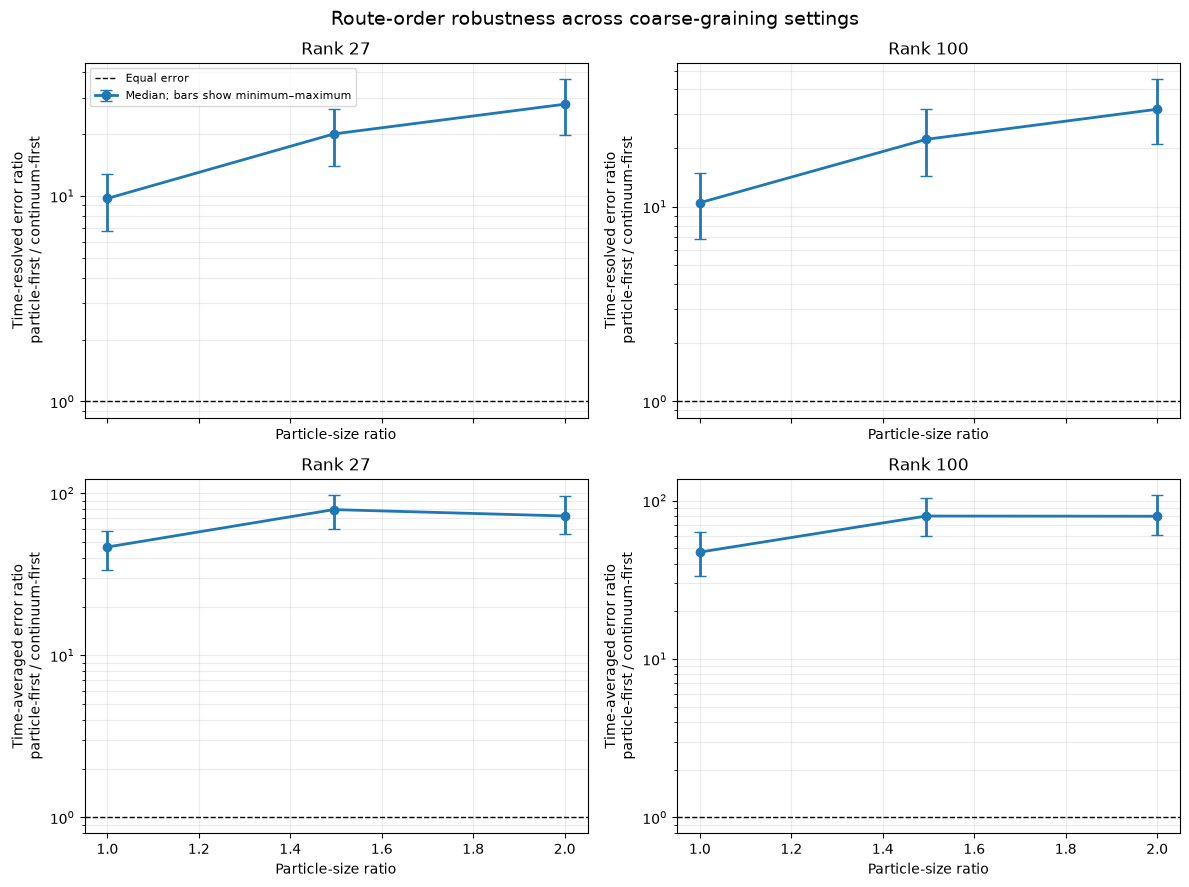

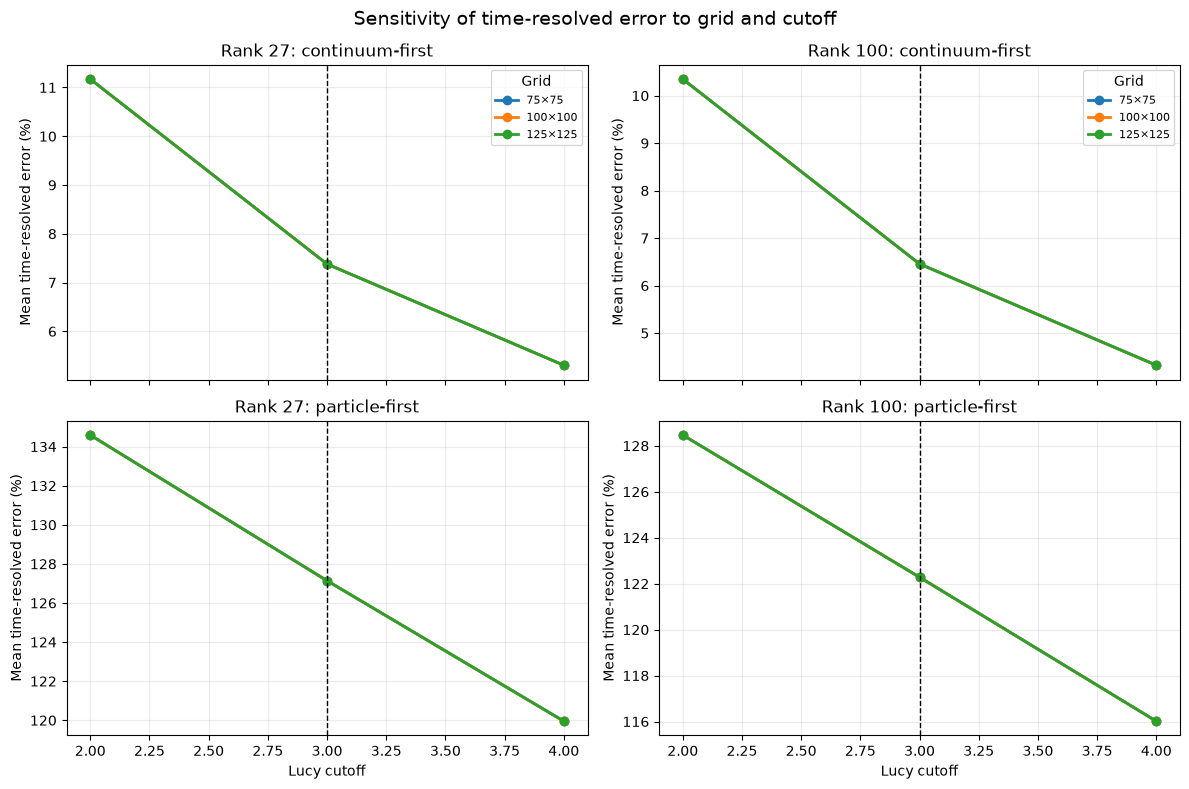

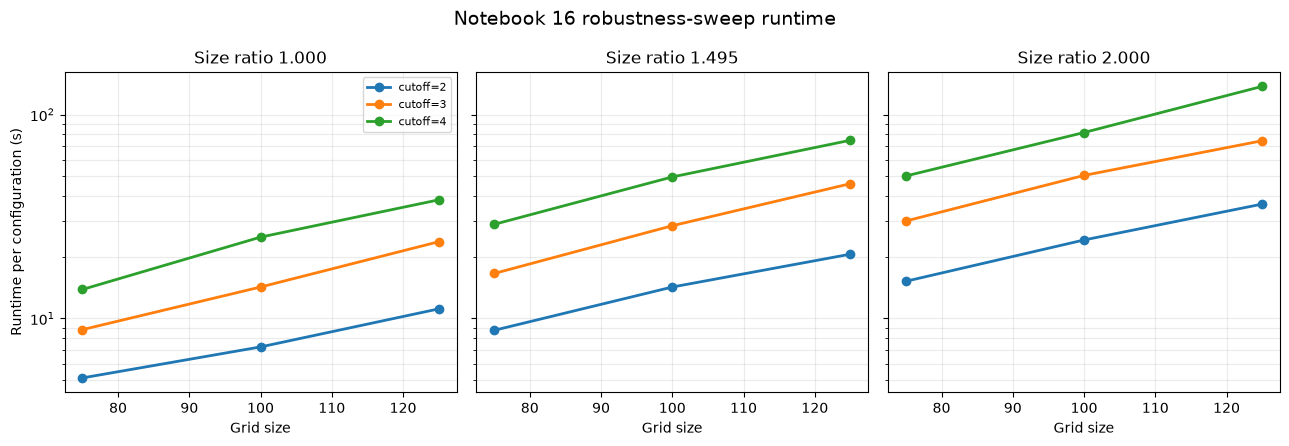

Saved Notebook 16 figures:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_robustness/route_order_ratio_robustness.pdf
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_robustness/route_order_ratio_robustness.png
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_robustness/route_order_error_sensitivity.pdf
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_robustness/route_order_error_sensitivity.png
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_robustness/route_order_runtime_summary.pdf
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_robustness/route_order_runtime_summary.png

Notebook 16 figures saved successfully: 6


In [24]:
import matplotlib.pyplot as plt


# ------------------------------------------------------------------
# Figure 1: route-order ratio ranges across all nine configurations
# ------------------------------------------------------------------

figure_ratio, axes_ratio = plt.subplots(
    2,
    2,
    figsize=(12, 9),
    sharex=True,
)

ratio_specs = [
    (
        0,
        n16_time_case_rank_robustness,
        "Time-resolved error ratio",
    ),
    (
        1,
        n16_average_case_rank_robustness,
        "Time-averaged error ratio",
    ),
]

for row, summary_table, row_label in ratio_specs:
    for column, rank in enumerate(N16_SWEEP_RANKS):
        axis = axes_ratio[row, column]

        subset = (
            summary_table.loc[
                summary_table["rank"].eq(rank)
            ]
            .sort_values("size_ratio")
            .copy()
        )

        assert len(subset) == len(N16_SWEEP_CASE_IDS)

        x_values = subset["size_ratio"].to_numpy(
            dtype=float
        )

        median_values = subset[
            "route_ratio_median"
        ].to_numpy(dtype=float)

        lower_errors = (
            median_values
            - subset["route_ratio_min"].to_numpy(
                dtype=float
            )
        )

        upper_errors = (
            subset["route_ratio_max"].to_numpy(
                dtype=float
            )
            - median_values
        )

        axis.errorbar(
            x_values,
            median_values,
            yerr=np.vstack(
                [
                    lower_errors,
                    upper_errors,
                ]
            ),
            marker="o",
            linewidth=2,
            capsize=4,
            label=(
                "Median; bars show "
                "minimum–maximum"
            ),
        )

        axis.axhline(
            1.0,
            color="black",
            linestyle="--",
            linewidth=1,
            label="Equal error",
        )

        axis.set_yscale("log")
        axis.grid(
            True,
            which="both",
            alpha=0.25,
        )

        axis.set_title(
            f"Rank {rank}"
        )

        axis.set_xlabel(
            "Particle-size ratio"
        )

        axis.set_ylabel(
            f"{row_label}\n"
            "particle-first / continuum-first"
        )

        if row == 0 and column == 0:
            axis.legend(
                fontsize=8,
                loc="upper left",
            )

figure_ratio.suptitle(
    "Route-order robustness across coarse-graining settings",
    fontsize=14,
)

figure_ratio.tight_layout()

N16_RATIO_FIGURE_PDF = (
    N16_FIGURE_DIRECTORY
    / "route_order_ratio_robustness.pdf"
)

N16_RATIO_FIGURE_PNG = (
    N16_FIGURE_DIRECTORY
    / "route_order_ratio_robustness.png"
)

figure_ratio.savefig(
    N16_RATIO_FIGURE_PDF,
    bbox_inches="tight",
)

figure_ratio.savefig(
    N16_RATIO_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------------
# Figure 2: time-resolved error sensitivity to cutoff and grid size
# ------------------------------------------------------------------

figure_error, axes_error = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharex=True,
)

for column, rank in enumerate(N16_SWEEP_RANKS):
    subset = (
        n16_time_configuration_summary.loc[
            n16_time_configuration_summary["rank"].eq(rank)
        ]
        .sort_values(["grid_size", "cutoff"])
        .copy()
    )

    for grid_size in N16_SWEEP_GRID_SIZES:
        grid_subset = subset.loc[
            subset["grid_size"].eq(grid_size)
        ].sort_values("cutoff")

        axes_error[0, column].plot(
            grid_subset["cutoff"],
            grid_subset["mean_continuum_error"],
            marker="o",
            linewidth=2,
            label=f"{grid_size}×{grid_size}",
        )

        axes_error[1, column].plot(
            grid_subset["cutoff"],
            grid_subset["mean_particle_error"],
            marker="o",
            linewidth=2,
            label=f"{grid_size}×{grid_size}",
        )

    axes_error[0, column].set_title(
        f"Rank {rank}: continuum-first"
    )

    axes_error[1, column].set_title(
        f"Rank {rank}: particle-first"
    )

    axes_error[0, column].set_ylabel(
        "Mean time-resolved error (%)"
    )

    axes_error[1, column].set_ylabel(
        "Mean time-resolved error (%)"
    )

    axes_error[1, column].set_xlabel(
        "Lucy cutoff"
    )

    for row in range(2):
        axes_error[row, column].axvline(
            3.0,
            color="black",
            linestyle="--",
            linewidth=1,
        )

        axes_error[row, column].grid(
            True,
            alpha=0.25,
        )

    axes_error[0, column].legend(
        fontsize=8,
        title="Grid",
    )

figure_error.suptitle(
    "Sensitivity of time-resolved error to grid and cutoff",
    fontsize=14,
)

figure_error.tight_layout()

N16_ERROR_FIGURE_PDF = (
    N16_FIGURE_DIRECTORY
    / "route_order_error_sensitivity.pdf"
)

N16_ERROR_FIGURE_PNG = (
    N16_FIGURE_DIRECTORY
    / "route_order_error_sensitivity.png"
)

figure_error.savefig(
    N16_ERROR_FIGURE_PDF,
    bbox_inches="tight",
)

figure_error.savefig(
    N16_ERROR_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------------
# Figure 3: computational runtime
# ------------------------------------------------------------------

figure_runtime, axes_runtime = plt.subplots(
    1,
    3,
    figsize=(13, 4.5),
    sharey=True,
)

for axis, case_id in zip(
    axes_runtime,
    N16_SWEEP_CASE_IDS,
):
    subset = n16_sweep_run_log.loc[
        n16_sweep_run_log["case_id"].eq(case_id)
    ].copy()

    for cutoff in N16_SWEEP_CUTOFFS:
        cutoff_subset = (
            subset.loc[
                subset["cutoff"].eq(cutoff)
            ]
            .sort_values("grid_size")
        )

        axis.plot(
            cutoff_subset["grid_size"],
            cutoff_subset["runtime_seconds"],
            marker="o",
            linewidth=2,
            label=f"cutoff={cutoff:g}",
        )

    size_ratio = float(
        subset["size_ratio"].iloc[0]
    )

    axis.set_title(
        f"Size ratio {size_ratio:.3f}"
    )

    axis.set_xlabel(
        "Grid size"
    )

    axis.set_yscale("log")
    axis.grid(
        True,
        which="both",
        alpha=0.25,
    )

axes_runtime[0].set_ylabel(
    "Runtime per configuration (s)"
)

axes_runtime[0].legend(
    fontsize=8,
)

figure_runtime.suptitle(
    "Notebook 16 robustness-sweep runtime",
    fontsize=14,
)

figure_runtime.tight_layout()

N16_RUNTIME_FIGURE_PDF = (
    N16_FIGURE_DIRECTORY
    / "route_order_runtime_summary.pdf"
)

N16_RUNTIME_FIGURE_PNG = (
    N16_FIGURE_DIRECTORY
    / "route_order_runtime_summary.png"
)

figure_runtime.savefig(
    N16_RUNTIME_FIGURE_PDF,
    bbox_inches="tight",
)

figure_runtime.savefig(
    N16_RUNTIME_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


n16_saved_figure_paths = [
    N16_RATIO_FIGURE_PDF,
    N16_RATIO_FIGURE_PNG,
    N16_ERROR_FIGURE_PDF,
    N16_ERROR_FIGURE_PNG,
    N16_RUNTIME_FIGURE_PDF,
    N16_RUNTIME_FIGURE_PNG,
]

assert all(
    path.is_file()
    for path in n16_saved_figure_paths
)

print("Saved Notebook 16 figures:")

for path in n16_saved_figure_paths:
    print(path)

print(
    "\nNotebook 16 figures saved successfully:",
    len(n16_saved_figure_paths),
)

## Notebook 16: route-order robustness

This notebook tests whether the route-order conclusion is robust to moderate changes in coarse-graining resolution and support radius.

The frozen sweep contains three representative cached DEM cases:

- size ratios 1.000000, 1.494949 and 2.000000;
- grid sizes \(75\times75\), \(100\times100\) and \(125\times125\);
- Lucy cutoffs \(2\), \(3\) and \(4\);
- POD ranks 27 and 100.

This gives 27 configurations. Each configuration uses the same 101/99 training/validation cycle split as the validated Notebook 12 analysis. No external parameter cases, particle `.data` files or new model selection steps are used.

### Main result

The particle-first route has larger error than the continuum-first route in every tested configuration.

The smallest observed particle-first/continuum-first ratio was:

- \(6.720868\) for the time-resolved error;
- \(33.618963\) for the time-averaged error.

Thus, the qualitative route-order conclusion is not dependent on a single grid or cutoff choice.

### Sensitivity to coarse-graining settings

Changing the grid from \(75\times75\) to \(125\times125\) produces only small changes in the reported errors and route ratios.

Changing the Lucy cutoff has a much larger effect on the absolute continuum-first error. Larger cutoffs reduce the continuum-first error in this sweep, while the particle-first route remains substantially worse. The cutoff-3, \(100\times100\) configuration reproduces the saved Notebook 12 baseline for all substantive numerical metrics to floating-point round-off.

The reported route-order conclusion should therefore be regarded as robust, while individual absolute error values remain dependent on the coarse-graining support radius.

### Threshold-sensitive diagnostic

The diagnostic `grid_fraction_phi_lt_zero_percent` differs slightly between the saved baseline and the regenerated sweep by \(0.04\)–\(0.09\) percentage points. This quantity counts values crossing a strict zero threshold and is sensitive to harmless floating-point sign changes near zero. It is retained as an audit diagnostic but is excluded from the substantive baseline-reproduction conclusion.

### Computational cost

The complete sweep required approximately 934.7 seconds. Runtime increased with grid size, cutoff and particle count. These timings are reconstruction diagnostics, not claims of forecasting speed-up.

### Interpretation and limitations

This notebook provides robustness evidence for the representation-order comparison. It does not constitute an independent parameter-generalisation test, because only three representative cached cases are used and the POD ranks and sweep settings were fixed in advance. No external test case was used for selection, fitting or threshold choice.

In [25]:
import hashlib
import json
from pathlib import Path


def n16_final_sha256(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:
        for block in iter(
            lambda: handle.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


# Recheck trusted inputs used by the sweep.
n16_trusted_input_records = []

for path_string, expected_hash in sorted(
    n16_input_hashes.items()
):
    path = Path(path_string).resolve()

    assert path.is_file()
    assert path.is_relative_to(PROJECT_ROOT)
    assert not path.is_relative_to(
        PROJECT_ROOT / "data" / "raw"
    )

    observed_hash = n16_final_sha256(path)

    assert observed_hash == expected_hash, (
        f"Trusted input changed: {path}"
    )

    n16_trusted_input_records.append(
        {
            "relative_path": str(
                path.relative_to(PROJECT_ROOT)
            ),
            "sha256": observed_hash,
        }
    )


# Hash the saved tables and figures.
n16_saved_artifact_paths = [
    *n16_saved_table_paths,
    *n16_saved_figure_paths,
]

assert len(n16_saved_artifact_paths) == 17
assert len(
    set(n16_saved_artifact_paths)
) == 17

n16_artifact_records = []

for path in n16_saved_artifact_paths:
    path = Path(path).resolve()

    assert path.is_file()
    assert path.is_relative_to(PROJECT_ROOT)

    if path.suffix == ".csv":
        role = "table_artifact"
    else:
        role = "figure_artifact"

    n16_artifact_records.append(
        {
            "relative_path": str(
                path.relative_to(PROJECT_ROOT)
            ),
            "role": role,
            "size_bytes": int(path.stat().st_size),
            "sha256": n16_final_sha256(path),
        }
    )


N16_MANIFEST_PATH = (
    N16_TABLE_DIRECTORY
    / "route_order_robustness_manifest.json"
)

n16_manifest_payload = {
    "schema_version": 1,
    "manifest_type": (
        "Notebook 16 route-order robustness "
        "artifact manifest"
    ),
    "analysis_status": "validated",
    "manifest_self_hash_excluded": True,
    "methodology": {
        "case_ids": list(N16_SWEEP_CASE_IDS),
        "grid_sizes": [
            int(value)
            for value in N16_SWEEP_GRID_SIZES
        ],
        "cutoffs": [
            float(value)
            for value in N16_SWEEP_CUTOFFS
        ],
        "pod_ranks": [
            int(value)
            for value in N16_SWEEP_RANKS
        ],
        "training_snapshot_count": 101,
        "validation_snapshot_count": 99,
        "comparison_time_max": float(N16_TIME_MAX),
        "axial_averaging_length": float(
            N16_AXIAL_LENGTH
        ),
        "baseline_grid_size": 100,
        "baseline_cutoff": 3.0,
        "source_function_sha256": n16_function_sha256,
    },
    "validation": {
        "pre_save_checks_passed": bool(
            n16_validation_checks["passed"].all()
        ),
        "substantive_baseline_reproduced": bool(
            n16_sweep_continuous_baseline_passed
        ),
        "threshold_sensitive_metric_flagged": bool(
            n16_sweep_threshold_diagnostic_flagged
        ),
        "minimum_time_resolved_ratio": float(
            n16_time_route_ratio_minimum
        ),
        "minimum_time_averaged_ratio": float(
            n16_average_route_ratio_minimum
        ),
        "threshold_metric_maximum_difference": float(
            n16_threshold_baseline_audit[
                "maximum_absolute_difference"
            ].max()
        ),
        "total_sweep_runtime_seconds": float(
            n16_sweep_run_log[
                "runtime_seconds"
            ].sum()
        ),
        "maximum_configuration_runtime_seconds": float(
            n16_sweep_run_log[
                "runtime_seconds"
            ].max()
        ),
        "validation_checks": json.loads(
            n16_validation_checks.to_json(
                orient="records"
            )
        ),
    },
    "scope": {
        "external_cases_included": False,
        "raw_dem_files_accessed": False,
        "raw_external_files_accessed": False,
        "files_written_before_validated_save": False,
        "threshold_sensitive_metric": (
            "grid_fraction_phi_lt_zero_percent"
        ),
    },
    "trusted_inputs": n16_trusted_input_records,
    "artifacts": n16_artifact_records,
    "artifact_count": len(n16_artifact_records),
}


N16_MANIFEST_PATH.write_text(
    json.dumps(
        n16_manifest_payload,
        indent=2,
        sort_keys=True,
    )
    + "\n",
    encoding="utf-8",
)

assert N16_MANIFEST_PATH.is_file()

n16_reloaded_manifest = json.loads(
    N16_MANIFEST_PATH.read_text(
        encoding="utf-8"
    )
)

assert (
    n16_reloaded_manifest["artifact_count"]
    == 17
)

assert (
    len(n16_reloaded_manifest["artifacts"])
    == 17
)

manifest_relative_path = str(
    N16_MANIFEST_PATH.relative_to(PROJECT_ROOT)
)

assert manifest_relative_path not in [
    record["relative_path"]
    for record in n16_reloaded_manifest[
        "artifacts"
    ]
]


# Verify every recorded artifact again.
for record in n16_reloaded_manifest[
    "artifacts"
]:
    path = PROJECT_ROOT / record["relative_path"]

    assert path.is_file()
    assert int(path.stat().st_size) == record[
        "size_bytes"
    ]
    assert n16_final_sha256(path) == record[
        "sha256"
    ]


N16_MANIFEST_SHA256 = n16_final_sha256(
    N16_MANIFEST_PATH
)

print(
    "Notebook 16 manifest:",
    N16_MANIFEST_PATH,
)

print(
    "Notebook 16 manifest SHA-256:",
    N16_MANIFEST_SHA256,
)

print(
    "Recorded artifacts:",
    len(n16_reloaded_manifest["artifacts"]),
)

print(
    "Trusted inputs rechecked:",
    len(n16_trusted_input_records),
)

print(
    "Manifest integrity verification passed:",
    True,
)

Notebook 16 manifest: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/route_order_robustness/route_order_robustness_manifest.json
Notebook 16 manifest SHA-256: 7e51ca1f2a47d6db07a0d827caed10b01efc2997648e70a75b0128adced90983
Recorded artifacts: 17
Trusted inputs rechecked: 16
Manifest integrity verification passed: True
